# Reinforcement Learning graded exercice #2

[Scikit-decide](https://github.com/airbus/scikit-decide) is an open-source library developed by Airbus to model and solve sequential decision-making problems such as reinforcement learning, planning and scheduling.
The documentation of the library can be found [here](https://airbus.github.io/scikit-decide/).

One benefit of scikit-decide relies on the opportunity to solve a problem of a given class, e.g. path planning problem, by using algorithms from different communities and to compare them, e.g. reinforcement learning and planning.

In this notebook, we will:
1. Solve classical RL benchmarks by using well-known RL frameworks which are directly accessible in scikit-decide.
2. Solve planning problems by using the same RL frameworks, demonstrating the ability of the library to solve planning problems seen as RL problems.
3. Solve an aircraft taxiing control problem by using RL algorithms.

Below are the import libraries that we will use throughout this notebook, after having downloaded the potentially missing packages.

In [1]:
from time import sleep
from typing import Optional, Callable

import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output

from stable_baselines3 import PPO
from ray.rllib.algorithms.dqn import DQN, DQNConfig

from skdecide import Solver, ImplicitSpace
from skdecide.hub.domain.gym import (
    GymDiscreteActionDomain,
    GymDomain,
    GymPlanningDomain,
    GymWidthDomain,
    GymDomainHashable
)
from skdecide.hub.solver.stable_baselines import StableBaseline
from skdecide.hub.solver.ray_rllib import RayRLlib
from skdecide.hub.solver.riw import RIW
from skdecide.hub.solver.cgp import CGP
from skdecide.hub.solver.mcts import UCT
from skdecide.utils import rollout as skd_rollout

# choose standard matplolib inline backend to render plots
%matplotlib inline

ModuleNotFoundError: No module named 'stable_baselines3'

## Solving classical RL benchmarks

We will consider the classical Cart Pole problem, as provided by Gymnasium and defined [here](https://gymnasium.farama.org/environments/classic_control/cart_pole/).

### Wrap Gymnasium environment in scikit-decide

We choose the gymnasium environment we would like to use.

In [2]:
ENV_NAME = "CartPole-v1"

We define a domain factory using GymDomain proxy available in scikit-decide which will wrap the Gym environment.

In [3]:
domain_factory = lambda: GymDomain(gym.make(ENV_NAME, render_mode="rgb_array"))

Here is a screenshot of such an environment.

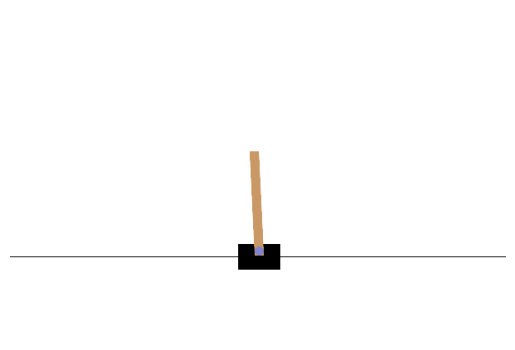

In [4]:
domain = domain_factory()
domain.reset()
plt.imshow(domain.render())
plt.axis("off")
domain.close()

### Solve with Reinforcement Learning (StableBaseline + PPO)

We first try a solver coming from the Reinforcement Learning community that is make use of OpenAI [stable_baselines3](https://github.com/DLR-RM/stable-baselines3), which give access to a lot of RL algorithms.

Here we choose [Proximal Policy Optimization (PPO)](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html) solver. It directly optimizes the weights of the policy network using stochastic gradient ascent. See more details in stable baselines [documentation](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html) and [original paper](https://arxiv.org/abs/1707.06347). 

#### Check compatibility
We check the compatibility of the domain with the chosen solver.

In [5]:
domain = domain_factory()
assert StableBaseline.check_domain(domain)
domain.close()

#### Solver instantiation

In [6]:
solver_factory = lambda: StableBaseline(
    domain_factory=domain_factory,
    algo_class=PPO,
    baselines_policy="MlpPolicy",
    learn_config={"total_timesteps": 10000},
    verbose=True
)

#### Training solver on domain

In [7]:
with solver_factory() as solver:
    solver.solve()
    solver.save("TEMP_Baselines")
    skd_rollout(
        domain,
        solver,
        num_episodes=1,
        max_steps=1000,
        max_framerate=30,
        outcome_formatter=None,
    )

/Users/teichteil_fl/Projects/AIBT108/aibt_108/.venv/lib/python3.12/site-packages/gymnasium/wrappers/compatibility.py:67: DeprecationWarning: WARN: The `gymnasium.make(..., apply_api_compatibility=...)` parameter is deprecated and will be removed in v0.29. Instead use `gym.make('GymV21Environment-v0', env_name=...)` or `from shimmy import GymV21CompatibilityV0`
  logger.deprecation(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 23       |
|    ep_rew_mean     | 23       |
| time/              |          |
|    fps             | 5361     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 26.8          |
|    ep_rew_mean          | 26.8          |
| time/                   |               |
|    fps                  | 3180          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.008235813   |
|    clip_fraction        | 0.0896        |
|    clip_range           | 0.2       

2026-04-13 11:56:40,355 | skdecide.utils | DEBUG | Logger is in verbose mode: all debug messages will be there for you to enjoy （〜^∇^ )〜
2026-04-13 11:56:40,356 | skdecide.utils | DEBUG | Episode 1 started with following observation:
2026-04-13 11:56:40,356 | skdecide.utils | DEBUG | [-0.0375399   0.01069545  0.01896316 -0.04006337]
2026-04-13 11:56:40,428 | skdecide.utils | DEBUG | Action: 1
2026-04-13 11:56:40,430 | skdecide.utils | DEBUG | Action: 0
2026-04-13 11:56:40,464 | skdecide.utils | DEBUG | Action: 1
2026-04-13 11:56:40,499 | skdecide.utils | DEBUG | Action: 0
2026-04-13 11:56:40,533 | skdecide.utils | DEBUG | Action: 0
2026-04-13 11:56:40,568 | skdecide.utils | DEBUG | Action: 1
2026-04-13 11:56:40,602 | skdecide.utils | DEBUG | Action: 1
2026-04-13 11:56:40,637 | skdecide.utils | DEBUG | Action: 0
2026-04-13 11:56:40,671 | skdecide.utils | DEBUG | Action: 0
2026-04-13 11:56:40,706 | skdecide.utils | DEBUG | Action: 1
2026-04-13 11:56:40,740 | skdecide.utils | DEBUG | Acti

#### Rolling out a solution

We can use the trained solver to roll out an episode to see if this is actually solving the problem at hand.

For educative purpose, we define here our own rollout (which will probably be needed if you want to actually use the solver in a real case). If you want to take a look at the (more complex) one already implemented in the library, see the `rollout()` function in [utils.py](https://github.com/airbus/scikit-decide/blob/master/skdecide/utils.py) module.

By default, we display the solution in a matplotlib figure. If you need only to check whether the goal is reached or not, you can specify `render=False`. In this case, the rollout is greatly speed up and a message is still printed at the end of process specifying success or not, with the number of steps required.

In [ ]:

def rollout(
    domain: GymDomain,
    solver: Solver,
    max_steps: int,
    pause_between_steps: Optional[float] = 0.01,
    render: bool = True,
):
    """Roll out one episode in a domain according to the policy of a trained solver.

    Args:
        domain: the maze domain to solve
        solver: a trained solver
        max_steps: maximum number of steps allowed to reach the goal
        pause_between_steps: time (s) paused between agent movements.
          No pause if None.
        render: if True, the rollout is rendered in a matplotlib figure as an animation;
            if False, speed up a lot the rollout.

    """
    # Initialize episode
    solver.reset()
    observation = domain.reset()

    # Initialize image
    if render:
        plt.ioff()
        fig, ax = plt.subplots(1)
        ax.axis("off")
        plt.ion()
        img = ax.imshow(domain.render(mode="rgb_array"))
        display(fig)

    # loop until max_steps or goal is reached
    is_goal_reached = False
    for i_step in range(1, max_steps + 1):
        if pause_between_steps is not None:
            sleep(pause_between_steps)

        # YOUR CODE HERE #
        # You must sample an action using the solver
        # then get the outcome from stepping the domain with this action
        # choose action according to solver
        
        action = solver.sample(observation)
        outcome = domain.step(action)
        
        observation = outcome.observation

        # update image
        if render:
            img.set_data(domain.render())
            fig.canvas.draw()
            clear_output(wait=True)
            display(fig)

        # final state reached?
        if outcome.termination:
            is_goal_reached = True
            break

    # close the figure to avoid jupyter duplicating the last image
    if render:
        plt.close(fig)

    return is_goal_reached, i_step

We create a domain for the roll out and close it at the end. If not closing it, an OpenGL popup windows stays open, at least on local Jupyter sessions.

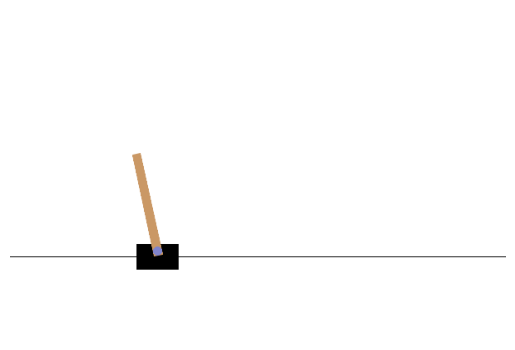

Goal not reached after 105 steps!


In [9]:
domain = domain_factory()
try:
    rollout(
        domain=domain,
        solver=solver,
        max_steps=1000,
        pause_between_steps=None,
        render=True,
    )
finally:
    domain.close()

#### Cleaning up

Some solvers need proper cleaning before being deleted.

In [10]:
solver._cleanup()

Note that this is automatically done if you use the solver within a `with` statement. The syntax would look something like:

```python
with solver_factory() as solver:
    MyDomain.solve_with(solver, domain_factory)
    rollout(domain=domain, solver=solver)
```

### Solve with Reinforcement Learning (RLLib + DQN)

For the sake of demonstration, we now show how to solve the same Cart Pole benchmark with a different RL library and algorithm: the [DQN](https://arxiv.org/abs/1312.5602v1) algorithm as implemented in the [Ray RLLib](https://docs.ray.io/en/latest/rllib/rllib-algorithms.html#dqn) library.

Interestingly, one can note that the domain definition is exactly the same as before. We just change the solving library and algorithm.

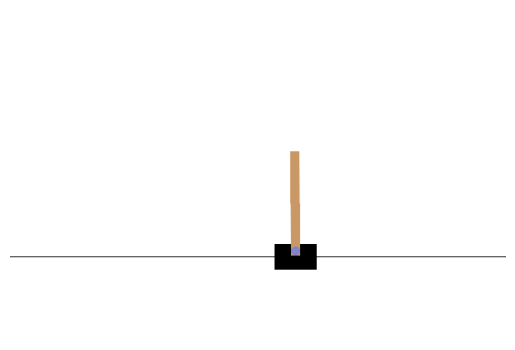

Goal not reached after 300 steps!


In [11]:
if RayRLlib.check_domain(domain):
    solver_factory = lambda: RayRLlib(
        domain_factory=domain_factory,
        algo_class=DQN,
        train_iterations=100,
        config=DQNConfig().training(n_step=300)
    )

    with solver_factory() as solver:
        solver.solve()

        # Test solution
        rollout(
            domain=domain,
            solver=solver,
            max_steps=300,
            pause_between_steps=None,
            render=True,
        )

## Solve with Cartesian Genetic Programming (CGP)

CGP (Cartesian Genetic Programming) is a form of genetic programming that uses a graph representation (2D grid of nodes) to encode computer programs. See [Miller, Julian. (2003). Cartesian Genetic Programming. 10.1007/978-3-642-17310-3.](https://www.researchgate.net/publication/2859242_Cartesian_Genetic_Programming) for more details.

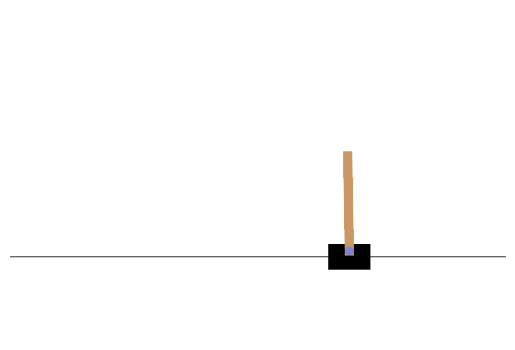

Goal reached in 1000 steps!


In [12]:
if CGP.check_domain(domain):
    solver_factory = lambda: CGP(
        domain_factory=domain_factory, folder_name="TEMP_CGP", n_it=1000, verbose=True
    )

    with solver_factory() as solver:
        solver.solve()

        # Test solution
        rollout(
            domain=domain,
            solver=solver,
            max_steps=1000,
            pause_between_steps=None,
            render=True,
        )

## Solve with Rollout Iterative Width

Iterated Width (IW) is a width based search algorithm that builds a graph on-demand, while pruning non-novel nodes.

In order to handle continuous domains, a state encoding specific to continuous state variables dynamically and adaptively discretizes the continuous state variables in such a way to build a compact graph based on intervals (rather than a naive grid of discrete point values).

The novelty measures discards intervals that are included in previously explored intervals, thus favoring to extend the state variable intervals.

See [this article ](https://www.ijcai.org/proceedings/2020/578) for more details.

Rollout IW is an online version of IW which explores a limited number of state-action trajectories pruned used novelty features within the allowed time budget.

### Prepare the domain for RIW

We need to wrap the Gym environment in a domain with finer charateristics so that IW can be used on it. More precisely, it needs the methods inherited from `GymPlanningDomain`, `GymDiscreteActionDomain` and `GymWidthDomain`. In addition, we will need to provide to RIW a state features function to dynamically increase state variable intervals. For Gym domains, we use Boundary Extension Encoding (BEE) features as explained in the [paper](https://www.ijcai.org/proceedings/2020/578) mentioned above. This is implemented as bee2_features() method in GymWidthDomain that our domain class will inherit.

In [25]:
class D(GymPlanningDomain, GymWidthDomain, GymDiscreteActionDomain):
    pass


class GymDomainForWidthSolvers(D):
    def __init__(
        self,
        gym_env: gym.Env,
        set_state: Callable[[gym.Env, D.T_memory[D.T_state]], None] = None,
        get_state: Callable[[gym.Env], D.T_memory[D.T_state]] = None,
        termination_is_goal: bool = True,
        continuous_feature_fidelity: int = 5,
        discretization_factor: int = 3,
        branching_factor: int = None,
        max_depth: int = 1000,
    ) -> None:
        GymPlanningDomain.__init__(
            self,
            gym_env=gym_env,
            set_state=set_state,
            get_state=get_state,
            termination_is_goal=termination_is_goal,
            max_depth=max_depth,
        )
        GymDiscreteActionDomain.__init__(
            self,
            discretization_factor=discretization_factor,
            branching_factor=branching_factor,
        )
        GymWidthDomain.__init__(
            self, continuous_feature_fidelity=continuous_feature_fidelity
        )
        gym_env._max_episode_steps = max_depth
        
    def _get_goals_(self):
        return ImplicitSpace(lambda observation: observation[0] >= 0.45)

In [26]:
domain4width_factory = lambda: GymDomainForWidthSolvers(
    gym.make(ENV_NAME, render_mode="rgb_array")
)

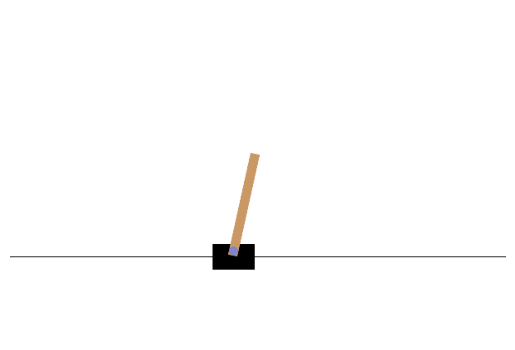

In [29]:
solver_factory = lambda: RIW(
    domain_factory=domain4width_factory,
    state_features=lambda d, s: d.bee2_features(s),
    use_state_feature_hash=False,
    use_simulation_domain=True,
    time_budget=500,
    rollout_budget=100000,
    max_depth=1000,
    exploration=0.25,
    online_node_garbage=True,
    continuous_planning=True,
    parallel=False,
    verbose=False,
)

with solver_factory() as solver:
    solver.solve()

    # Test solution
    rollout(
        domain=domain4width_factory(),
        solver=solver,
        max_steps=1000,
        pause_between_steps=None,
        render=True,
    )

## Solving with MCTS/UCT

[MCTS](https://en.wikipedia.org/wiki/Monte_Carlo_tree_search) and its [UCT](https://en.wikipedia.org/wiki/Monte_Carlo_tree_search#Exploration_and_exploitation) variant are famous online tree search/simulation algorithms for search-based reinforcement learning. They have been used a lot in chess and Go solvers, including their [AlphaGo](https://en.wikipedia.org/wiki/AlphaGo) extension which won against the world champion human Go player in 2016.

In [ ]:
solver_factory = lambda: UCT(
    domain_factory=domain4width_factory,
    time_budget=200,
    rollout_budget=100000,
    online_node_garbage=True,
    max_depth=1000,
    parallel=False,
    verbose=False,
)

with solver_factory() as solver:
    solver.solve()

    # Test solution
    rollout(
        domain=domain4width_factory(),
        solver=solver,
        max_steps=1000,
        pause_between_steps=None,
        render=True,
    )

## Compare different approaches

We will use scikit-decide's functionality to benchmark and compare different algorithms.

Follow [this](https://github.com/airbus/scikit-decide/blob/master/notebooks/14_benchmarking_tuto.ipynb) tutorial to do the same with the solvers above on the cart-pole domain.

In [ ]:
# Benchmarking and comparing solvers on CartPole-v1
# We use scikit-decide's built-in benchmarking utilities to compare the performance of different solvers.

from skdecide.hub.benchmark import benchmark

# Define the solvers to compare. Each entry is a tuple (solver_name, solver_factory)
solvers = [
    ("StableBaseline_PPO", lambda: StableBaseline(
        domain_factory=domain_factory,
        algo_class=PPO,
        baselines_policy="MlpPolicy",
        learn_config={"total_timesteps": 10000},
        verbose=False
    )),
    ("RayRLlib_DQN", lambda: RayRLlib(
        domain_factory=domain_factory,
        algo_class=DQN,
        train_iterations=100,
        config=DQNConfig().training(n_step=300)
    )),
    ("CGP", lambda: CGP(
        domain_factory=domain_factory,
        folder_name="TEMP_CGP",
        n_it=1000,
        verbose=False
    )),
    ("RIW", lambda: RIW(
        domain_factory=domain4width_factory,
        state_features=lambda d, s: d.bee2_features(s),
        use_state_feature_hash=False,
        use_simulation_domain=True,
        time_budget=500,
        rollout_budget=100000,
        max_depth=1000,
        exploration=0.25,
        online_node_garbage=True,
        continuous_planning=True,
        parallel=False,
        verbose=False,
    )),
    ("UCT", lambda: UCT(
        domain_factory=domain4width_factory,
        time_budget=200,
        rollout_budget=100000,
        online_node_garbage=True,
        max_depth=1000,
        parallel=False,
        verbose=False,
    ))
]

# Run the benchmark
results = benchmark(
    domain_factory=domain_factory,
    solver_factories=solvers,
    num_runs=3,  # Number of runs per solver for averaging
    max_steps=500,
    verbose=True
)

# Plot the results for comparison
benchmark.plot_benchmark_results(results)

# The plot will show the average performance (e.g., episode reward or steps to solve) for each solver.
# This allows you to visually compare the efficiency and effectiveness of each approach on CartPole-v1.